In [ ]:
import joblib
import numpy as np
import pandas as pd

model = joblib.load('kmeans_model.pkl')
scaler = joblib.load('scaler.pkl')


In [2]:
df = pd.read_csv("../datasets/PRDECT-ID Dataset.csv")

In [5]:
df = df.drop(["Category", "Product Name", "Location", "Total Review", "Customer Rating", "Customer Review", "Sentiment", "Emotion"], axis=1)

In [6]:
df.head()

,Price,Overall Rating,Number Sold
0,53500,4.9,5449
1,72000,4.9,2359
2,213000,5.0,12300
3,55000,4.7,2030
4,55000,4.7,2030


In [7]:
df["log_price"] = np.log1p(df["Price"])
df["log_sold_count"] = np.log1p(df["Number Sold"])

In [8]:
features_to_scale = df[["log_price", "Overall Rating", "log_sold_count"]]

X_scaled = scaler.transform(features_to_scale)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd

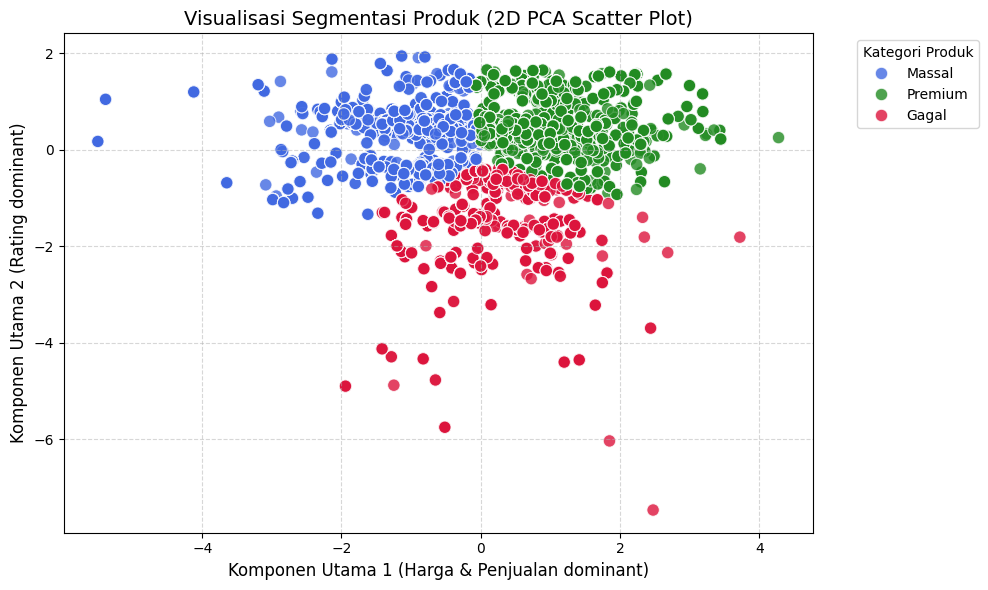

In [13]:
cluster_id = model.predict(X_scaled)
label_map = {0: "Gagal", 1: "Massal", 2: "Premium"} 

segments = [label_map.get(e, "Niche") for e in cluster_id]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_viz = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Segment': segments
})

plt.figure(figsize=(10, 6))

custom_palette = {
    "Premium": "forestgreen", 
    "Massal": "royalblue", 
    "Gagal": "crimson", 
    "Niche": "gray"
}

sns.scatterplot(
    data=df_viz, 
    x='PCA1', 
    y='PCA2', 
    hue='Segment', 
    palette=custom_palette, 
    alpha=0.8,
    s=80 
)

plt.title("Visualisasi Segmentasi Produk (2D PCA Scatter Plot)", fontsize=14)
plt.xlabel("Komponen Utama 1 (Harga & Penjualan dominant)", fontsize=12)
plt.ylabel("Komponen Utama 2 (Rating dominant)", fontsize=12)
plt.legend(title='Kategori Produk', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
